<a href="https://colab.research.google.com/github/Snp-Rj-Ind-code-error-420/CBSOT-CHURN/blob/main/Code_block_ml_customer_segmentation_and_churn_predection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.express as px
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_excel('/content/Telco_customer_churn.xlsx')
df.sample(4)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
5704,0786-IVLAW,1,United States,California,Valley Village,91607,"34.165783, -118.399795",34.165783,-118.399795,Female,...,One year,No,Bank transfer (automatic),108.10,7238.6,No,0,20,4722,NaN
2366,8755-OGKNA,1,United States,California,Laton,93242,"36.444232, -119.718285",36.444232,-119.718285,Female,...,Two year,No,Bank transfer (automatic),19.50,1167.6,No,0,45,5864,NaN
1650,7153-OANIO,1,United States,California,Mendocino,95460,"39.305545, -123.743697",39.305545,-123.743697,Male,...,Month-to-month,No,Electronic check,69.95,69.95,Yes,1,79,5066,Moved
4081,2207-QPJED,1,United States,California,Somes Bar,95568,"41.444606, -123.471895",41.444606,-123.471895,Female,...,Month-to-month,No,Electronic check,90.00,3371.75,No,0,62,4048,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [4]:
df.shape

(7043, 33)

In [5]:
df['Churn Label'].value_counts()

,count
Churn Label,
No,5174
Yes,1869


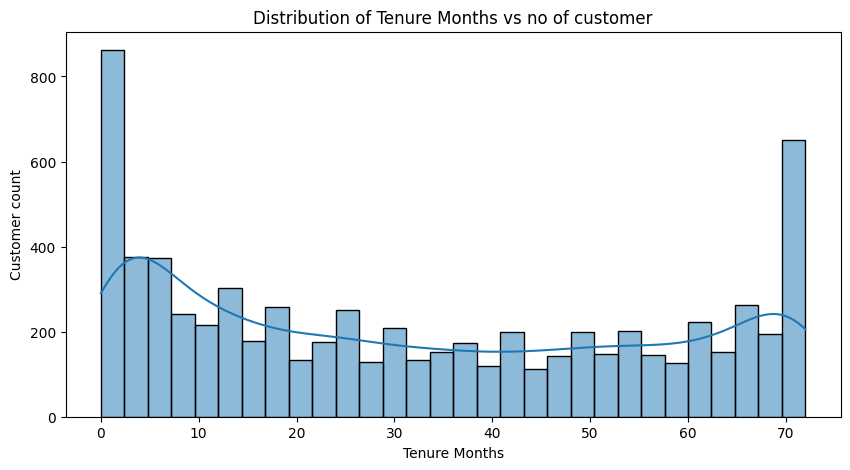

In [6]:
plt.figure(figsize=(10,5))
sns.histplot(df['Tenure Months'],bins=30,kde=True)
plt.xlabel('Tenure Months')
plt.ylabel('Customer count')
plt.title('Distribution of Tenure Months vs no of customer')
plt.show()

In [7]:
df['Tenure Months'].max(),df['Tenure Months'].min()

(72, 0)

In [8]:
(72-0)/30

2.4

<Axes: xlabel='Tenure Months', ylabel='Count'>

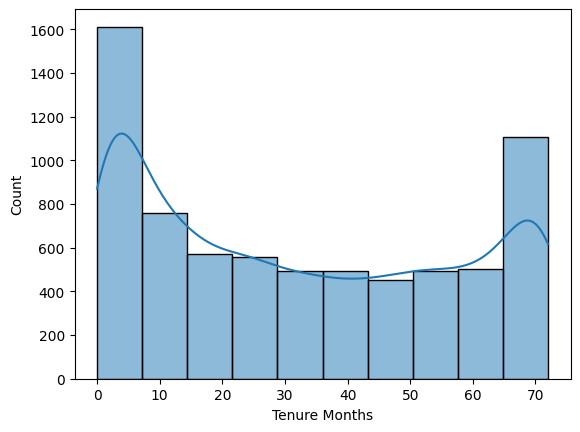

In [9]:
sns.histplot(df['Tenure Months'],bins=10,kde=True)

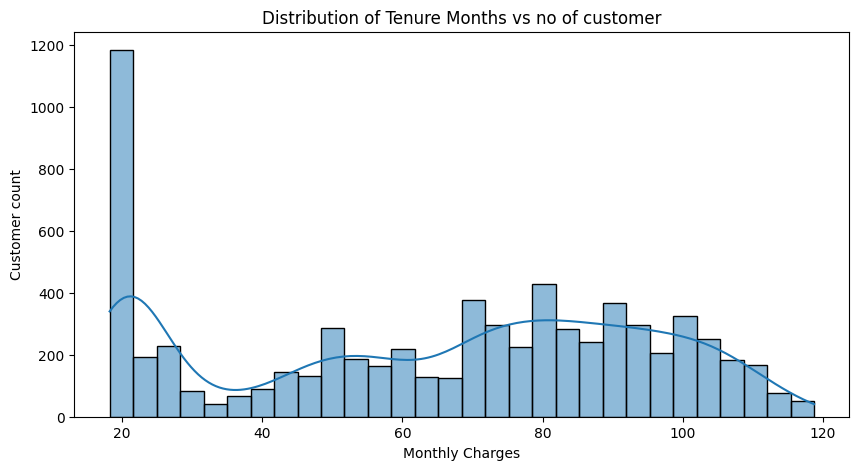

In [10]:
plt.figure(figsize=(10,5))
sns.histplot(df['Monthly Charges'],bins=30,kde=True)
plt.xlabel('Monthly Charges')
plt.ylabel('Customer count')
plt.title('Distribution of Tenure Months vs no of customer')
plt.show()

In [11]:
df['Monthly Charges'].max(),df['Monthly Charges'].min()

(118.75, 18.25)

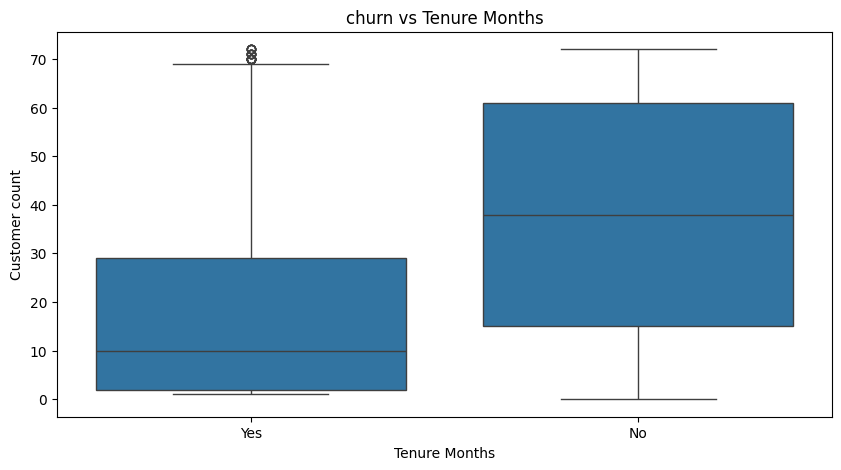

In [12]:
plt.figure(figsize=(10,5))
sns.boxplot(y='Tenure Months',x='Churn Label',data=df)
plt.xlabel('Tenure Months')
plt.ylabel('Customer count')
plt.title('churn vs Tenure Months')
plt.show()

after 10 month the churn but person availing for 32 months are continuing to avaling it

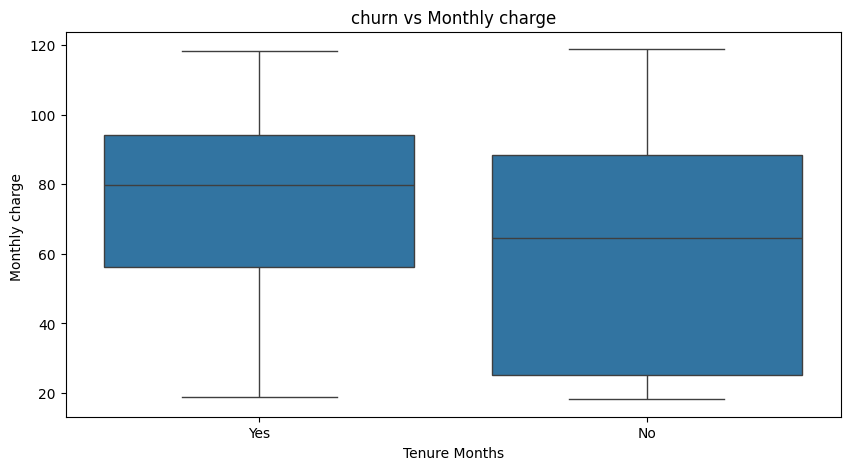

In [13]:
plt.figure(figsize=(10,5))
sns.boxplot(y='Monthly Charges',x='Churn Label',data=df)
plt.xlabel('Tenure Months')
plt.ylabel('Monthly charge ')
plt.title('churn vs Monthly charge')
plt.show()

In [14]:
df['Churn Label'].unique()

array(['Yes', 'No'], dtype=object)

In [15]:
df[df['Churn Label']=='Yes']['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,56.15
0.50,79.65
0.75,94.20


In [16]:
df[df['Churn Label']=='No']['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,25.100
0.50,64.425
0.75,88.400


In [17]:
df['Monthly Charges'].describe()

,Monthly Charges
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


In [18]:
df['Contract'].unique()

array(['Month-to-month', 'Two year', 'One year'], dtype=object)

In [19]:
df['Contract'].value_counts()

,count
Contract,
Month-to-month,3875
Two year,1695
One year,1473


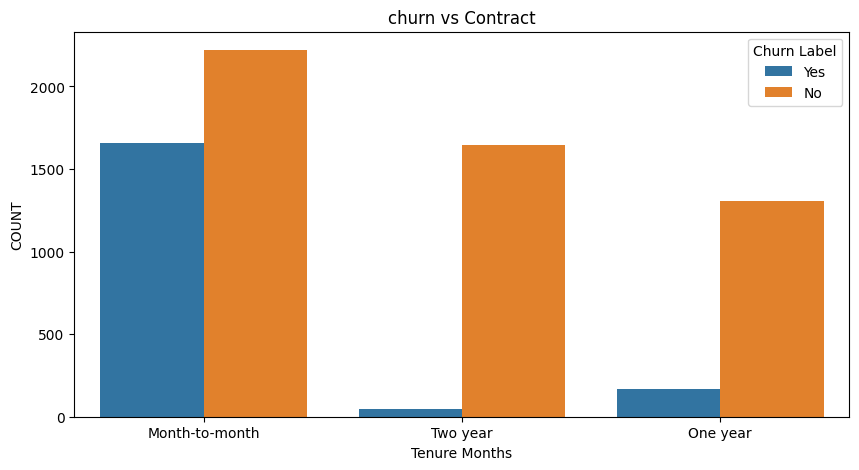

In [20]:
plt.figure(figsize=(10,5))
sns.countplot(x='Contract',hue='Churn Label',data=df)
plt.xlabel('Tenure Months')
plt.ylabel('COUNT')
plt.title('churn vs Contract')
plt.show()
#month to month have high churn rate

In [21]:
df['Internet Service'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

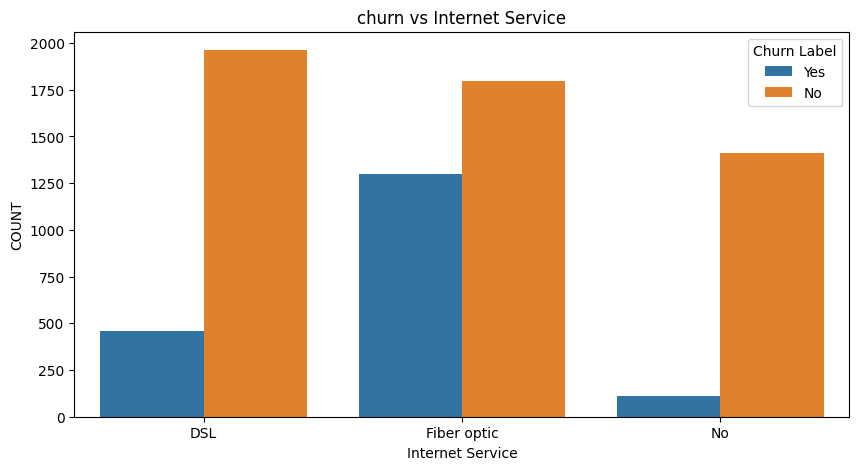

In [22]:
plt.figure(figsize=(10,5))
sns.countplot(x='Internet Service',hue='Churn Label',data=df)
plt.xlabel('Internet Service')
plt.ylabel('COUNT')
plt.title('churn vs Internet Service')
plt.show()
# premiup service have high churn rate

In [23]:
df['Payment Method'].unique()

array(['Mailed check', 'Electronic check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

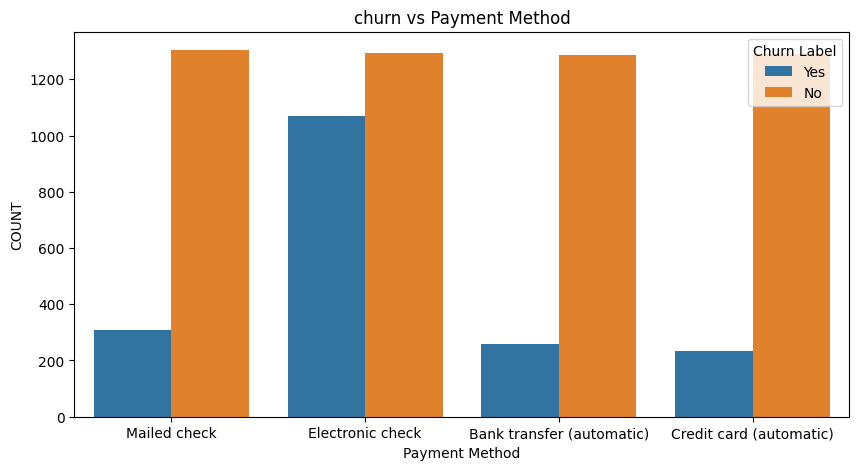

In [24]:
plt.figure(figsize=(10,5))
sns.countplot(x='Payment Method',hue='Churn Label',data=df)
plt.xlabel('Payment Method')
plt.ylabel('COUNT')
plt.title('churn vs Payment Method')
plt.show()
# high churn for electronic check
# inertia automatic -> peopel it will required strong reason for change

In [25]:
df['Tech Support'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

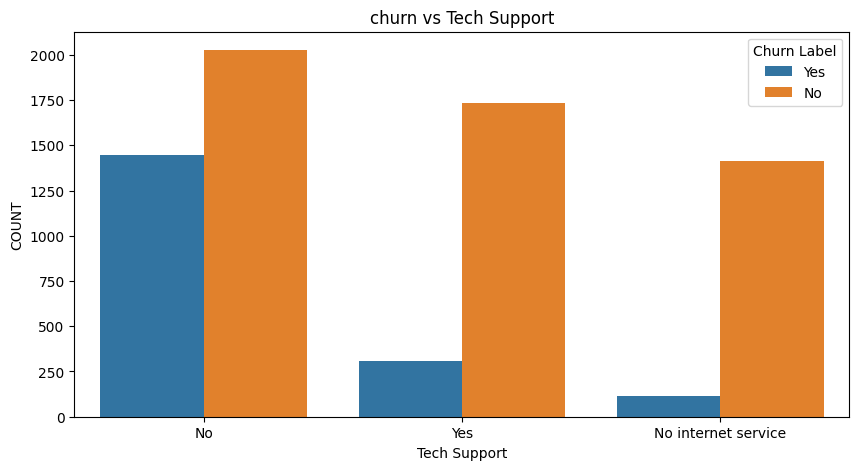

In [26]:
plt.figure(figsize=(10,5))
sns.countplot(x='Tech Support',hue='Churn Label',data=df)
plt.xlabel('Tech Support')
plt.ylabel('COUNT')
plt.title('churn vs Tech Support')
plt.show()

In [27]:
avg_tenure=df.groupby('Churn Label')['Tenure Months'].mean()
avg_tenure

,Tenure Months
Churn Label,
No,37.569965
Yes,17.979133


In [28]:
fig = px.bar(df.groupby(['City'])['CustomerID'].count().reset_index().sort_values('CustomerID',ascending=False).head(50),
             x='City',
             y='CustomerID',
             color = 'CustomerID',
             text = 'CustomerID')
fig.show()

In [29]:
fig = px.histogram(df, x="Tenure Months", color="Churn Label",marginal="box" )
fig.show()

In [30]:
fig = px.bar(df.groupby(['Churn Reason'])['CustomerID'].count().reset_index().sort_values('CustomerID',
                                                                                    ascending=False),
             x='Churn Reason',
             y='CustomerID',
             color = 'CustomerID',
             text = 'CustomerID')
fig.show()

In [31]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [32]:
num_col=['Tenure Months','Monthly Charges','Churn Value','Churn Score','CLTV']

In [33]:
corr_mt=df[num_col].corr()
corr_mt

,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
Tenure Months,1.000000,0.247900,-0.352229,-0.224987,0.396406
Monthly Charges,0.247900,1.000000,0.193356,0.133754,0.098693
Churn Value,-0.352229,0.193356,1.000000,0.664897,-0.127463
Churn Score,-0.224987,0.133754,0.664897,1.000000,-0.079782
CLTV,0.396406,0.098693,-0.127463,-0.079782,1.000000


<Axes: >

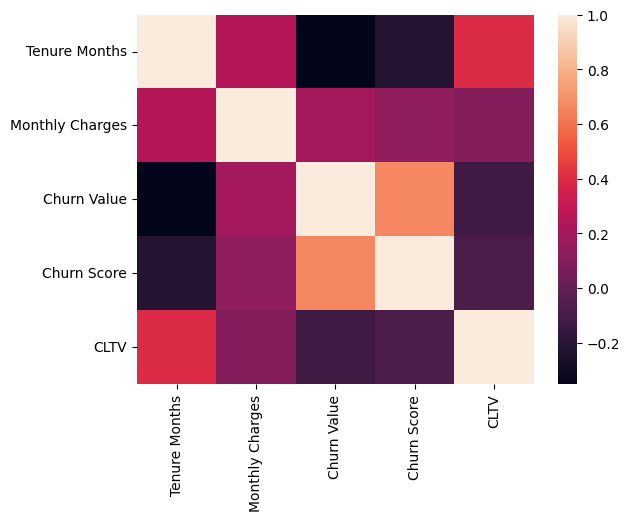

In [34]:

sns.heatmap(corr_mt)

In [35]:
Contract_churn =pd.crosstab(df['Contract'],df['Churn Label'])
Contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [36]:
Contract_churn =pd.crosstab(df['Contract'],df['Churn Label'],normalize='index')
Contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


In [37]:
tech_support_churn =pd.crosstab(df['Tech Support'],df['Churn Label'])
tech_support_churn

Churn Label,No,Yes
Tech Support,,
No,2027,1446
No internet service,1413,113
Yes,1734,310


# data cleaning

In [38]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [39]:
df['Total Charges'].unique()

array([108.15, 151.65, 820.5, ..., 7362.9, 346.45, 6844.5], dtype=object)

In [40]:
df['Total Charges']=pd.to_numeric(df['Total Charges'],errors='coerce')

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [42]:
df['Total Charges'].isnull().sum()

np.int64(11)

In [43]:
df[df['Total Charges'].isnull()]['Tenure Months']

,Tenure Months
2234,0
2438,0
2568,0
2667,0
2856,0
4331,0
4687,0
5104,0
5719,0
6772,0


In [44]:
df[df['Tenure Months']==0]

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
2234,4472-LVYGI,1,United States,California,San Bernardino,92408,"34.084909, -117.258107",34.084909,-117.258107,Female,...,Two year,Yes,Bank transfer (automatic),52.55,NaN,No,0,36,2578,NaN
2438,3115-CZMZD,1,United States,California,Independence,93526,"36.869584, -118.189241",36.869584,-118.189241,Male,...,Two year,No,Mailed check,20.25,NaN,No,0,68,5504,NaN
2568,5709-LVOEQ,1,United States,California,San Mateo,94401,"37.590421, -122.306467",37.590421,-122.306467,Female,...,Two year,No,Mailed check,80.85,NaN,No,0,45,2048,NaN
2667,4367-NUYAO,1,United States,California,Cupertino,95014,"37.306612, -122.080621",37.306612,-122.080621,Male,...,Two year,No,Mailed check,25.75,NaN,No,0,48,4950,NaN
2856,1371-DWPAZ,1,United States,California,Redcrest,95569,"40.363446, -123.835041",40.363446,-123.835041,Female,...,Two year,No,Credit card (automatic),56.05,NaN,No,0,30,4740,NaN
4331,7644-OMVMY,1,United States,California,Los Angeles,90029,"34.089953, -118.294824",34.089953,-118.294824,Male,...,Two year,No,Mailed check,19.85,NaN,No,0,53,2019,NaN
4687,3213-VVOLG,1,United States,California,Sun City,92585,"33.739412, -117.173334",33.739412,-117.173334,Male,...,Two year,No,Mailed check,25.35,NaN,No,0,49,2299,NaN
5104,2520-SGTTA,1,United States,California,Ben Lomond,95005,"37.078873, -122.090386",37.078873,-122.090386,Female,...,Two year,No,Mailed check,20.00,NaN,No,0,27,3763,NaN
5719,2923-ARZLG,1,United States,California,La Verne,91750,"34.144703, -117.770299",34.144703,-117.770299,Male,...,One year,Yes,Mailed check,19.70,NaN,No,0,69,4890,NaN
6772,4075-WKNIU,1,United States,California,Bell,90201,"33.970343, -118.171368",33.970343,-118.171368,Female,...,Two year,No,Mailed check,73.35,NaN,No,0,44,2342,NaN


In [45]:
[7043-7032,(11/7043)]

[11, 0.001561834445548772]

In [46]:
df['Total Charges']=df['Total Charges'].fillna(0)

In [47]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [48]:
drop_columns=['CustomerID','Count','Country','State','Zip Code','Lat Long','Latitude','Longitude','Churn Label',
              'Churn Score','CLTV','Churn Reason']

df=df.drop(columns=drop_columns)

In [49]:
df.shape

(7043, 21)

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7043 non-null   object 
 1   Gender             7043 non-null   object 
 2   Senior Citizen     7043 non-null   object 
 3   Partner            7043 non-null   object 
 4   Dependents         7043 non-null   object 
 5   Tenure Months      7043 non-null   int64  
 6   Phone Service      7043 non-null   object 
 7   Multiple Lines     7043 non-null   object 
 8   Internet Service   7043 non-null   object 
 9   Online Security    7043 non-null   object 
 10  Online Backup      7043 non-null   object 
 11  Device Protection  7043 non-null   object 
 12  Tech Support       7043 non-null   object 
 13  Streaming TV       7043 non-null   object 
 14  Streaming Movies   7043 non-null   object 
 15  Contract           7043 non-null   object 
 16  Paperless Billing  7043 

In [51]:
df['City'].unique()

array(['Los Angeles', 'Beverly Hills', 'Huntington Park', ..., 'Standish',
       'Tulelake', 'Olympic Valley'], dtype=object)

In [52]:
df=df.drop(columns='City')

In [53]:
df_encode=pd.get_dummies(df,drop_first=True)

In [54]:
df_encode.head()

,Tenure Months,Monthly Charges,Total Charges,Churn Value,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,1,True,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
1,2,70.70,151.65,1,False,False,False,True,True,False,...,False,False,False,False,False,False,True,False,True,False
2,8,99.65,820.50,1,False,False,False,True,True,False,...,False,True,False,True,False,False,True,False,True,False
3,28,104.80,3046.05,1,False,False,True,True,True,False,...,False,True,False,True,False,False,True,False,True,False
4,49,103.70,5036.30,1,True,False,False,True,True,False,...,False,True,False,True,False,False,True,False,False,False


In [55]:
df_encode.columns

Index(['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Value',
       'Gender_Male', 'Senior Citizen_Yes', 'Partner_Yes', 'Dependents_Yes',
       'Phone Service_Yes', 'Multiple Lines_No phone service',
       'Multiple Lines_Yes', 'Internet Service_Fiber optic',
       'Internet Service_No', 'Online Security_No internet service',
       'Online Security_Yes', 'Online Backup_No internet service',
       'Online Backup_Yes', 'Device Protection_No internet service',
       'Device Protection_Yes', 'Tech Support_No internet service',
       'Tech Support_Yes', 'Streaming TV_No internet service',
       'Streaming TV_Yes', 'Streaming Movies_No internet service',
       'Streaming Movies_Yes', 'Contract_One year', 'Contract_Two year',
       'Paperless Billing_Yes', 'Payment Method_Credit card (automatic)',
       'Payment Method_Electronic check', 'Payment Method_Mailed check'],
      dtype='object')

In [56]:
X=df_encode.drop(columns='Churn Value')
# drop('churn Value,axis=1)
y=df_encode['Churn Value']

In [57]:
X.shape,y.shape

((7043, 30), (7043,))

In [58]:
df['Churn Value'].value_counts()

,count
Churn Value,
0,5174
1,1869


In [59]:
# X.info()
(5174/7043)*100,(1869/7043)*100


(73.4630129206304, 26.536987079369588)

# machine learning implementation

In [60]:
from sklearn.model_selection import train_test_split

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

In [62]:
X_train.shape,X_test.shape ,y_train.shape,y_test.shape

((5634, 30), (1409, 30), (5634,), (1409,))

In [63]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,recall_score,precision_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import SMOTENC
#ML MODELS
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier ,GradientBoostingClassifier,VotingClassifier
import xgboost as xgb
# from CHAID import Tree

In [64]:
model=RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

In [65]:
accuracy_score(y_test,y_pred)

0.7856635911994322

In [66]:
confusion_matrix(y_test,y_pred)

array([[902, 107],
       [195, 205]])

In [67]:
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1009
           1       0.66      0.51      0.58       400

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.78      1409



In [68]:
# df['Churn Value'].value_counts()

# Approach handeling imbalance data

In [69]:
balance_model=RandomForestClassifier(n_estimators=100,random_state=42,class_weight='balanced')
balance_model.fit(X_train,y_train)
y_pred=balance_model.predict(X_test)

In [70]:
accuracy_score(y_test,y_pred)

0.7920511000709723

In [71]:
confusion_matrix(y_test,y_pred)

array([[907, 102],
       [191, 209]])

In [72]:
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1009
           1       0.67      0.52      0.59       400

    accuracy                           0.79      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



#hyper parameter Tuning

In [73]:
hp_balance_model2=RandomForestClassifier(n_estimators=300,random_state=42,max_depth=10,class_weight='balanced')
hp_balance_model2.fit(X_train,y_train)
y_pred=hp_balance_model2.predict(X_test)

In [74]:
accuracy_score(y_test,y_pred)


0.7828246983676366

In [75]:
confusion_matrix(y_test,y_pred)

array([[804, 205],
       [101, 299]])

In [76]:
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1009
           1       0.59      0.75      0.66       400

    accuracy                           0.78      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.80      0.78      0.79      1409



In [77]:
hp_balance_model=RandomForestClassifier(n_estimators=100,
                                        max_depth=3,
                                        random_state=42,
                                        class_weight='balanced')
hp_balance_model.fit(X_train,y_train)
y_pred=hp_balance_model.predict(X_test)
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.730305180979418
[[704 305]
 [ 75 325]]
              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1009
           1       0.52      0.81      0.63       400

    accuracy                           0.73      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.79      0.73      0.74      1409



In [78]:
hp_balance_model=RandomForestClassifier(n_estimators=800,
                                        max_depth=131,
                                        random_state=42,
                                        class_weight='balanced')
hp_balance_model.fit(X_train,y_train)
y_pred=hp_balance_model.predict(X_test)
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.7877927608232789
[[907 102]
 [197 203]]
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1009
           1       0.67      0.51      0.58       400

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.78      1409



## ensomble learning

In [79]:
voting_clf_best_hard = VotingClassifier(
    estimators=[
         ('xgb1',xgb.XGBClassifier(n_estimators=210, max_depth=4,
                learning_rate=0.01,
                random_state=42)),
         ("xgb2",xgb.XGBClassifier(n_estimators=100, max_depth=3,
                learning_rate=0.01,
                random_state=42)),
         ("Gd",xgb.XGBClassifier(n_estimators=143, max_depth=10,
                learning_rate=0.01,
                random_state=42)),
        ("gd2",RandomForestClassifier(n_estimators=100,
                                        max_depth=3,
                                        random_state=42,
                                        class_weight='balanced'))
    ],
    voting='soft',
    weights=[1,2,1,3]
)

In [80]:
voting_clf_best_hard.fit(X_train,y_train)
y_pred=voting_clf_best_hard.predict(X_test)
print("best hard voting accuracy",accuracy_score(y_test,y_pred))
print("Accuracy",accuracy_score(y_test,y_pred)*100)
print(confusion_matrix(y_test,y_pred,))
print(classification_report(y_test,y_pred))

best hard voting accuracy 0.8034066713981547
Accuracy 80.34066713981547
[[904 105]
 [172 228]]
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1009
           1       0.68      0.57      0.62       400

    accuracy                           0.80      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



## approach feature importance analysis

<Axes: xlabel='Importance', ylabel='Features'>

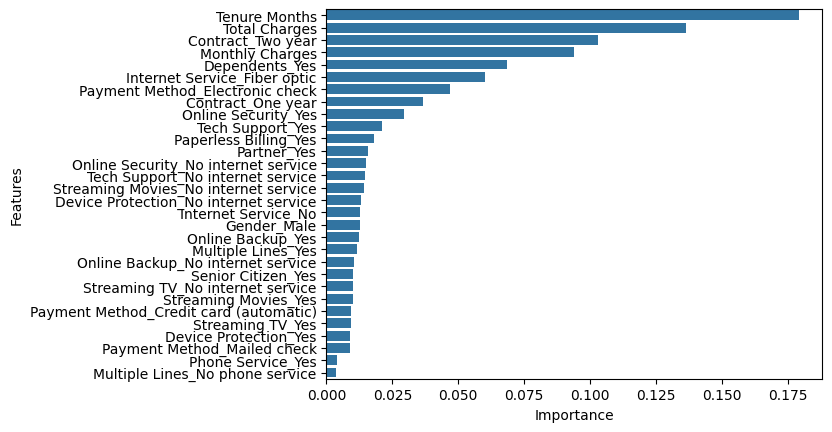

In [81]:
# import panda as pd
fi=pd.DataFrame({
    'Features':X.columns,
    'Importance':hp_balance_model2.feature_importances_
})
fi=fi.sort_values('Importance',ascending=False)
# fi

sns.barplot(y=fi['Features'],x=fi['Importance'])
# plt.xticks(rotation=90)

In [82]:
fi.tail(10)

,Features,Importance
14,Online Backup_No internet service,0.010298
4,Senior Citizen_Yes,0.010257
20,Streaming TV_No internet service,0.010186
23,Streaming Movies_Yes,0.010161
27,Payment Method_Credit card (automatic),0.009430
21,Streaming TV_Yes,0.009289
17,Device Protection_Yes,0.009101
29,Payment Method_Mailed check,0.008800
7,Phone Service_Yes,0.003872
8,Multiple Lines_No phone service,0.003725


In [83]:
x_select=X.drop(['Phone Service_Yes','Multiple Lines_No phone service'],axis=1)

In [84]:
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    x_select, y, test_size=0.20, random_state=42)


In [85]:
hp_balance_model3=RandomForestClassifier(n_estimators=300,
                                        max_depth=10,
                                        random_state=42,
                                        class_weight='balanced')
hp_balance_model3.fit(X_train_sel,y_train_sel)
y_pred=hp_balance_model3.predict(X_test_sel)
print(accuracy_score(y_test_sel,y_pred))
print(confusion_matrix(y_test_sel,y_pred))
print(classification_report(y_test_sel,y_pred))

0.7835344215755855
[[807 202]
 [103 297]]
              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1009
           1       0.60      0.74      0.66       400

    accuracy                           0.78      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.80      0.78      0.79      1409



In [86]:
# approach combination

approach combination  of tree and depth

In [87]:
n_estimators_list=[100,200,300,400,500]
max_depth_list=[5,10,12,15,20]
result=[]
for n_trees in n_estimators_list:
  for depth in max_depth_list:
    hp_balance_model=RandomForestClassifier(n_estimators=n_trees,
                                        max_depth=depth,
                                        random_state=42,
                                        class_weight='balanced')
    hp_balance_model.fit(X_train_sel,y_train_sel)
    y_pred=hp_balance_model.predict(X_test_sel)
    accuracy=accuracy_score(y_test_sel,y_pred)
    recall=recall_score(y_test_sel,y_pred)
    precision=precision_score(y_test_sel,y_pred)
    result.append({
        'n_trees':n_trees,
        'depth':depth,
        'accuracy':accuracy,
        'recall':recall,
        'precision':precision
    })

In [88]:
rs=pd.DataFrame(result)
rs.sort_values(['recall','accuracy'],inplace=True,ascending=False)
rs

,n_trees,depth,accuracy,recall,precision
20,500,5,0.740951,0.8100,0.528548
15,400,5,0.741661,0.8075,0.529508
0,100,5,0.743080,0.8050,0.531353
10,300,5,0.738112,0.8025,0.525368
5,200,5,0.738822,0.8000,0.526316
21,500,10,0.786373,0.7575,0.597633
16,400,10,0.784244,0.7500,0.595238
1,100,10,0.779986,0.7450,0.588933
11,300,10,0.783534,0.7425,0.595190
6,200,10,0.777857,0.7425,0.585799


In [89]:
hp_balance_model=RandomForestClassifier(n_estimators=500,
                                        max_depth=15,
                                        random_state=42,
                                        class_weight='balanced')
hp_balance_model.fit(X_train_sel,y_train_sel)
y_pred=hp_balance_model.predict(X_test_sel)
print(accuracy_score(y_test_sel,y_pred))
print(confusion_matrix(y_test_sel,y_pred))
print(classification_report(y_test_sel,y_pred))

0.8062455642299503
[[880 129]
 [144 256]]
              precision    recall  f1-score   support

           0       0.86      0.87      0.87      1009
           1       0.66      0.64      0.65       400

    accuracy                           0.81      1409
   macro avg       0.76      0.76      0.76      1409
weighted avg       0.80      0.81      0.81      1409



In [90]:
hp_balance_model=RandomForestClassifier(n_estimators=300,
                                        max_depth=10,
                                        random_state=42,
                                        class_weight='balanced')
hp_balance_model.fit(X_train_sel,y_train_sel)
y_pred=hp_balance_model.predict(X_test_sel)
print(accuracy_score(y_test_sel,y_pred))
print(confusion_matrix(y_test_sel,y_pred))
print(classification_report(y_test_sel,y_pred))

0.7835344215755855
[[807 202]
 [103 297]]
              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1009
           1       0.60      0.74      0.66       400

    accuracy                           0.78      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.80      0.78      0.79      1409



In [91]:
from sklearn.model_selection import cross_val_score
fianal_rf=RandomForestClassifier(n_estimators=300,
                                        max_depth=10,
                                        random_state=42,
                                        class_weight='balanced')


In [92]:
cv_accuracy=cross_val_score(fianal_rf,X,y,cv=5,scoring='accuracy')
print(cv_accuracy)
print(cv_accuracy.mean())


[0.76721079 0.79772889 0.76224273 0.78551136 0.78409091]
0.7793569343183432


In [93]:
cv_accuracy=cross_val_score(fianal_rf,X,y,cv=5,scoring='recall')
print(cv_accuracy)
print(cv_accuracy.mean())


[0.70855615 0.76470588 0.74064171 0.74331551 0.71045576]
0.7335350030823931


In [94]:
from sklearn.metrics import roc_auc_score,roc_curve

In [95]:
y_prob=hp_balance_model2.predict_proba(X_test)
y_prob=y_prob[:,1]
y_prob2=hp_balance_model3.predict_proba(x_select)
y_prob2=y_prob2[:,1]
y_prob.shape,y_prob2.shape

((1409,), (7043,))

In [96]:
fpr,tpr,treshold=roc_curve(y_test,y_prob)
auc_score=roc_auc_score(y_test,y_prob)
print(auc_score)

0.857104806739346


## Customer Segmentation

In [97]:
df.columns

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value'],
      dtype='object')

In [98]:
df.shape


(7043, 20)

In [99]:
segmentation_data=pd.DataFrame({
    'Tenure Months':df['Tenure Months'],
    'Monthly Charges':df['Monthly Charges'],
    'Total Charges':df['Total Charges'],
    'Churn probablity':y_prob2
})


In [100]:
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn probablity
0,2,53.85,108.15,0.679494
1,2,70.70,151.65,0.798181
2,8,99.65,820.50,0.805994
3,28,104.80,3046.05,0.563508
4,49,103.70,5036.30,0.512996
...,...,...,...,...
7038,72,21.15,1419.40,0.002734
7039,24,84.80,1990.50,0.065898
7040,72,103.20,7362.90,0.050338
7041,11,29.60,346.45,0.337597


In [101]:
scaler=StandardScaler()
segmentation_data_scaled=scaler.fit_transform(segmentation_data)

In [102]:
std=pd.DataFrame(segmentation_data_scaled)
std

,0,1,2,3
0,-1.236724,-0.362660,-0.958066,1.030588
1,-1.236724,0.197365,-0.938874,1.416299
2,-0.992402,1.159546,-0.643789,1.441691
3,-0.177995,1.330711,0.338085,0.653654
4,0.677133,1.294151,1.216150,0.489501
...,...,...,...,...
7038,1.613701,-1.449476,-0.379565,-1.168761
7039,-0.340876,0.665992,-0.127605,-0.963489
7040,1.613701,1.277533,2.242606,-1.014056
7041,-0.870241,-1.168632,-0.852932,-0.080516


<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

...

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

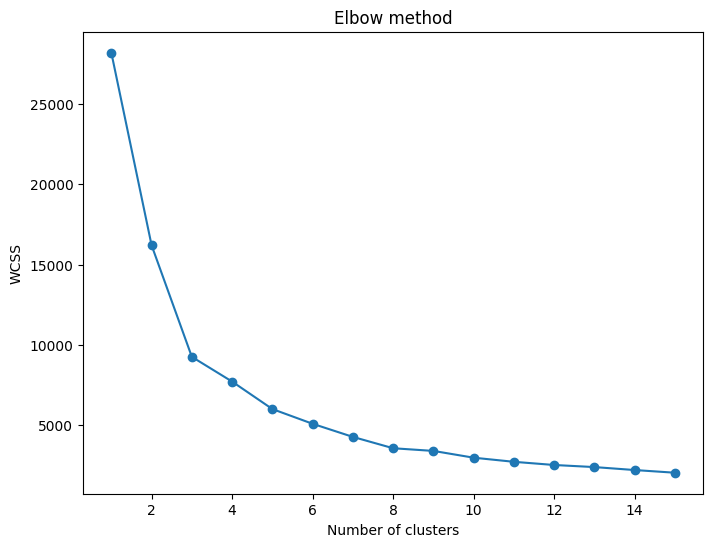

In [103]:
from sklearn.cluster import KMeans
wcss=[]
for k in range(1,16):
  kmeans=KMeans(n_clusters=k,random_state=42)
  kmeans.fit(segmentation_data_scaled)
  wcss.append(kmeans.inertia_)
  plt.figure(figsize=(8,6))
plt.plot(range(1,16),wcss,marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.title('Elbow method')
plt.show()

In [104]:
kmeans=KMeans(n_clusters=3,random_state=42)
# kmeans.fit(segmentation_data_scaled)
cluster=kmeans.fit_predict(segmentation_data_scaled)

In [105]:
segmentation_data['cluster']=cluster

In [106]:
segmentation_data.sample(5)

,Tenure Months,Monthly Charges,Total Charges,Churn probablity,cluster
6472,3,19.90,45.75,0.230512,0
3240,71,19.45,1378.45,0.000313,0
3102,6,25.40,153.30,0.032916,0
3703,56,75.85,4261.20,0.014954,1
5170,57,53.35,3090.05,0.075567,0


In [107]:
cluster_summary=segmentation_data.groupby('cluster').mean()
cluster_summary

,Tenure Months,Monthly Charges,Total Charges,Churn probablity
cluster,,,,
0,31.591141,32.906218,1033.619037,0.126090
1,58.315303,90.347573,5265.253768,0.227619
2,10.931280,72.445103,884.868602,0.696599


In [108]:
cluster_summary={
    0:'Budget Loyal Customer',
    1:'High risk new Customer',
    2:'Loyal premium Customer'
}

In [109]:
segmentation_data['quality']=segmentation_data['cluster'].map(cluster_summary)
segmentation_data.sample(5)

,Tenure Months,Monthly Charges,Total Charges,Churn probablity,cluster,quality
148,65,105.25,6786.40,0.505291,1,High risk new Customer
6346,61,69.90,4226.70,0.018205,1,High risk new Customer
4915,56,98.60,5581.05,0.583477,1,High risk new Customer
3931,15,48.85,736.80,0.434540,2,Loyal premium Customer
821,17,70.00,1144.50,0.732139,2,Loyal premium Customer


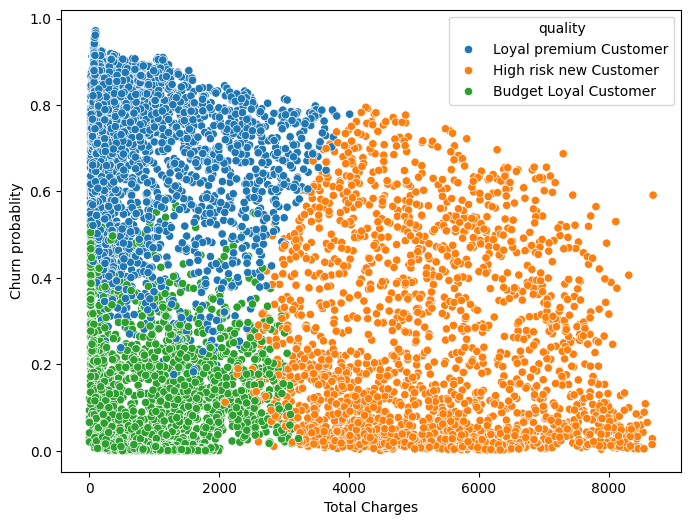

In [110]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Total Charges',y='Churn probablity',data=segmentation_data,hue='quality')
plt.show()
#

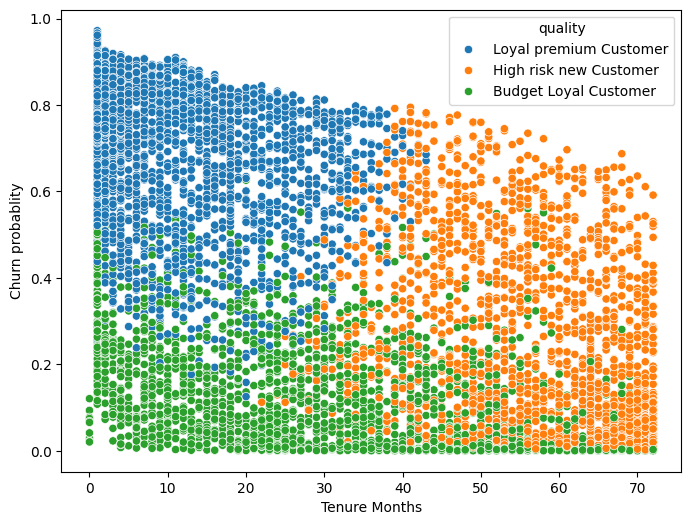

In [111]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Tenure Months',y='Churn probablity',data=segmentation_data,hue='quality')
plt.show()

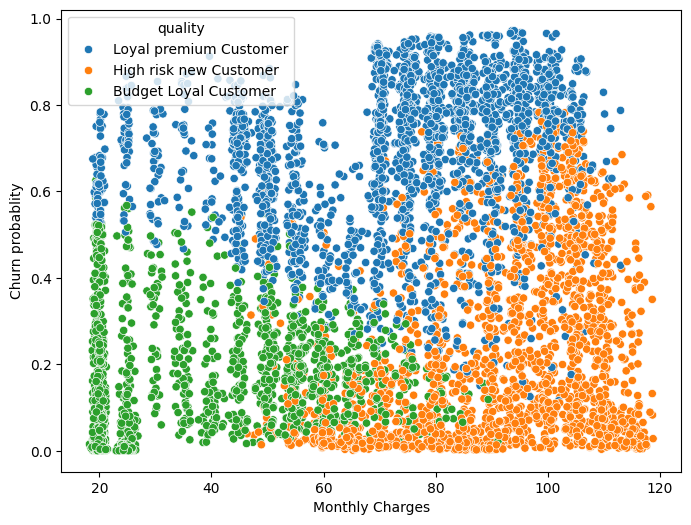

In [112]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Monthly Charges',y='Churn probablity',data=segmentation_data,hue='quality')
plt.show()